In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import pandas as pd

In [47]:
df = pd.read_csv("../trajectory/center.csv", )

df.head()

,x,y
0,-1.521231,-3.000000
1,-2.332818,-3.022545
2,-2.779765,-4.004922
3,-4.229000,-3.777533
4,-4.871000,-3.699014


In [48]:
for _ in range(2):
    df2 = pd.DataFrame({
        'x' : df['x'] + np.random.uniform(-0.1, 0.1, size=len(df)),
        'y' : df['y'] + np.random.uniform(-0.1, 0.1, size=len(df))
    }) 
    print(len(df2))
    df = pd.concat([df, df2],  ignore_index=True)

9
18


/tmp/ipykernel_11347/580710375.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


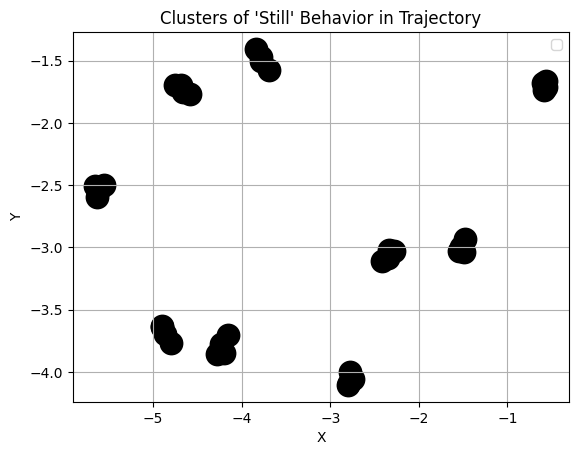

In [49]:
for _, row in df.iterrows():
    plt.scatter(row['x'], row['y'], marker='o', s=200, linewidths=3, color='black')

plt.legend()
plt.title("Clusters of 'Still' Behavior in Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [50]:
gmm = GaussianMixture(
    n_components=10,        # number of Gaussian components
    covariance_type='full',
    random_state=42
)

gmm.fit(df)               
labels = gmm.predict(df)

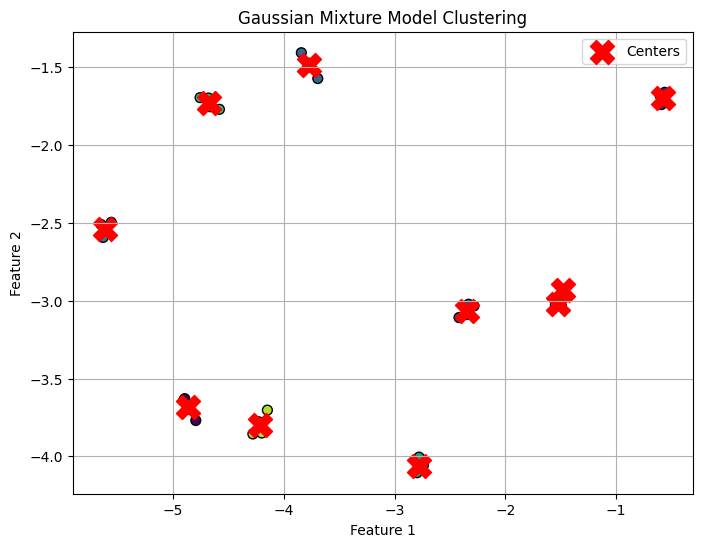

In [51]:
plt.figure(figsize=(8, 6))

# scatter points colored by hard labels
plt.scatter(df['x'], df['y'], c=labels, cmap='viridis', s=50, edgecolor='k')

# plot Gaussian centers
plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centers'
)

plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.legend()
plt.show()